# Kansas Well Log Analysis
## Petrophysical Formation Evaluation - KGS Public Dataset
** Author: Tarun Joshi**  
** Data Source: Kansas Geological Survey (KGS) - Public Domain **

This notebook loads a real LAS file from a Kansas oil & gas well,
performs formation evaluation, and identifies reservoir intervals
using GR, resistivity, density, neutron, and Vshale analysis.

In [2]:
# ── Imports ────────────────────────────────────────────────────────────
import lasio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator

print("All packages loaded successfully")
print(f"lasio version: {lasio.__version__}")

All packages loaded successfully
lasio version: 0.32


In [3]:
las = lasio.read("kansas_well.las")
print(f"Well: {las.well.WELL.value}")
print(f"Curves: {[c.mnemonic for c in las.curves]}")
df = las.df().reset_index()
print(f"Depth range: {df.iloc[:,0].min():.1f} to {df.iloc[:,0].max():.1f} ft")
print(f"Total points: {len(df)}")
print(df.head())

Well: ROGER #10-4
Curves: ['DEPT', 'MEL15', 'MEL20', 'MELCAL', 'ABHV', 'CNPOR', 'DCAL', 'DPOR', 'GR', 'RHOB', 'RHOC', 'RILD', 'RILM', 'RLL3', 'RXORT', 'SP', 'TBHV']
Depth range: 0.0 to 3629.0 ft
Total points: 7259
   DEPT  MEL15  MEL20  MELCAL  ABHV    CNPOR    DCAL      DPOR        GR  \
0   0.0    NaN    NaN     NaN   0.0 -20.0834 -2.2510  103.5562  312.3020   
1   0.5    NaN    NaN     NaN   0.0 -20.6618 -2.2538   49.2896  288.7107   
2   1.0    NaN    NaN     NaN   0.0 -20.4227 -2.2479   32.4002  295.9166   
3   1.5    NaN    NaN     NaN   0.0 -19.3087 -2.2398   36.1578  346.4977   
4   2.0    NaN    NaN     NaN   0.0 -17.2457 -2.2465   65.0949  407.6735   

     RHOB    RHOC     RILD  RILM       RLL3     RXORT        SP  TBHV  
0  0.9392 -0.6307  21.3885   NaN        NaN       NaN -160.6110   0.0  
1  1.8671  0.1704  27.3750   NaN        NaN       NaN -161.2411   0.0  
2  2.1560  0.3728  49.7641   NaN        NaN       NaN -161.4460   0.0  
3  2.0917  0.2856   1.7073   NaN  3993.18

In [4]:
# ── Clean the dataframe ─────────────────────────────────────────────────
# Rename depth column
df = df.rename(columns={'DEPT': 'DEPTH'})

# Drop rows where key curves are all NaN
key_curves = ['GR', 'RHOB', 'CNPOR', 'RILD']
df = df.dropna(subset=key_curves).reset_index(drop=True)

print(f"Clean data points: {len(df)}")
print(f"Depth range: {df['DEPTH'].min():.1f} to {df['DEPTH'].max():.1f} ft")
print(f"GR range: {df['GR'].min():.1f} to {df['GR'].max():.1f} API")

Clean data points: 7185
Depth range: 0.0 to 3592.0 ft
GR range: 0.0 to 432.7 API


In [5]:
GR_min = df['GR'].quantile(0.05)
GR_max = df['GR'].quantile(0.95)

df['VSHALE'] = (df['GR'] - GR_min) / (GR_max - GR_min)
df['VSHALE'] = df['VSHALE'].clip(0, 1)

print(f"GR clean sand baseline (P5):  {GR_min:.1f} API")
print(f"GR shale baseline (P95):      {GR_max:.1f} API")

GR clean sand baseline (P5):  32.4 API
GR shale baseline (P95):      121.2 API


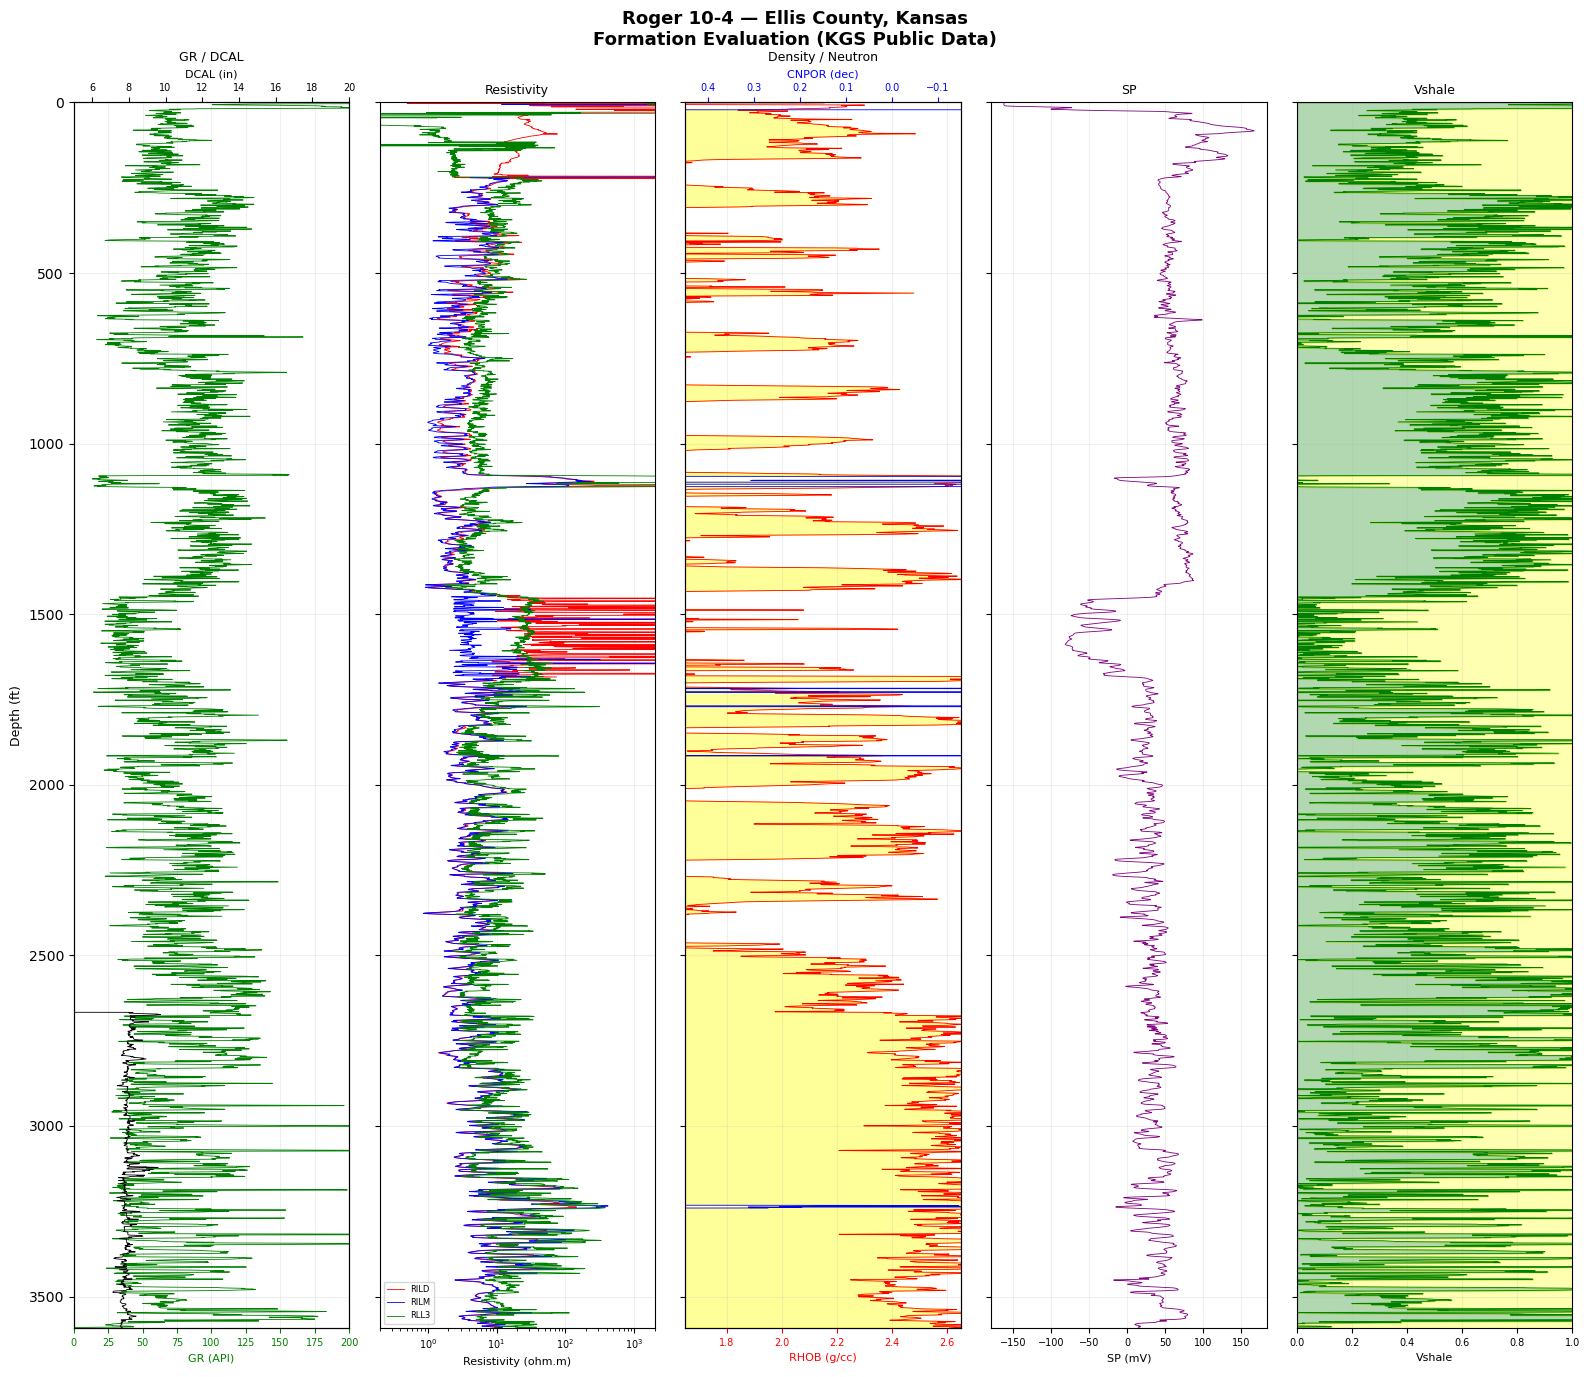

In [6]:
# ── 5-Track Formation Evaluation Display ───────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(16, 14), sharey=True)
fig.suptitle('Roger 10-4 — Ellis County, Kansas\nFormation Evaluation (KGS Public Data)', 
             fontsize=13, fontweight='bold')

depth = df['DEPTH']

# Track 1: GR + Caliper
ax1 = axes[0]
ax1b = ax1.twiny()
ax1.plot(df['GR'], depth, color='green', linewidth=0.6)
ax1b.plot(df['DCAL'], depth, color='black', linewidth=0.6)
ax1.set_xlim(0, 200)
ax1b.set_xlim(5, 20)
ax1.set_xlabel('GR (API)', color='green', fontsize=8)
ax1b.set_xlabel('DCAL (in)', color='black', fontsize=8)
ax1.tick_params(axis='x', colors='green', labelsize=7)
ax1b.tick_params(axis='x', colors='black', labelsize=7)
ax1.set_ylabel('Depth (ft)', fontsize=9)
ax1.set_title('GR / DCAL', fontsize=9)

# Track 2: Resistivity
ax2 = axes[1]
ax2.semilogx(df['RILD'], depth, color='red', linewidth=0.6, label='RILD')
ax2.semilogx(df['RILM'], depth, color='blue', linewidth=0.6, label='RILM')
ax2.semilogx(df['RLL3'], depth, color='green', linewidth=0.6, label='RLL3')
ax2.set_xlim(0.2, 2000)
ax2.set_xlabel('Resistivity (ohm.m)', fontsize=8)
ax2.set_title('Resistivity', fontsize=9)
ax2.legend(fontsize=6)

# Track 3: Density + Neutron
ax3 = axes[2]
ax3b = ax3.twiny()
ax3.plot(df['RHOB'], depth, color='red', linewidth=0.6)
ax3b.plot(df['CNPOR'], depth, color='blue', linewidth=0.6)
ax3.set_xlim(1.65, 2.65)
ax3b.set_xlim(0.45, -0.15)
ax3.set_xlabel('RHOB (g/cc)', color='red', fontsize=8)
ax3b.set_xlabel('CNPOR (dec)', color='blue', fontsize=8)
ax3.tick_params(axis='x', colors='red', labelsize=7)
ax3b.tick_params(axis='x', colors='blue', labelsize=7)
ax3.set_title('Density / Neutron', fontsize=9)

# Neutron-Density crossover fill (light fluid flag)
ax3.fill_betweenx(depth,
    df['RHOB'].values,
    np.interp(df['CNPOR'].values, 
              np.linspace(-0.15, 0.45, 100), 
              np.linspace(2.65, 1.65, 100)),
    where=(df['CNPOR'].values > 0.15),
    color='yellow', alpha=0.4, label='Crossover')

# Track 4: SP
ax4 = axes[3]
ax4.plot(df['SP'], depth, color='purple', linewidth=0.6)
ax4.set_xlabel('SP (mV)', fontsize=8)
ax4.set_title('SP', fontsize=9)

# Track 5: Vshale
ax5 = axes[4]
ax5.plot(df['VSHALE'], depth, color='green', linewidth=0.6)
ax5.fill_betweenx(depth, 0, df['VSHALE'], color='green', alpha=0.3)
ax5.fill_betweenx(depth, df['VSHALE'], 1, color='yellow', alpha=0.3)
ax5.set_xlim(0, 1)
ax5.set_xlabel('Vshale', fontsize=8)
ax5.set_title('Vshale', fontsize=9)

# Shared formatting
for ax in axes:
    ax.set_ylim(depth.max(), depth.min())
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.show()

In [7]:
fig.savefig('roger10_4_formation_evaluation.png', dpi=150, bbox_inches='tight')
print("Plot saved!")

Plot saved!


In [8]:
# ── Porosity Calculation ────────────────────────────────────────────────
# Density porosity formula: PHID = (RHOMA - RHOB) / (RHOMA - RHOF)
# RHOMA = matrix density (2.65 g/cc for sandstone)
# RHOF  = fluid density (1.0 g/cc for freshwater, 1.1 for saltwater)

RHOMA = 2.65  # sandstone matrix
RHOF  = 1.0   # freshwater

df['PHID'] = (RHOMA - df['RHOB']) / (RHOMA - RHOF)
df['PHID'] = df['PHID'].clip(0, 0.4)  # physical limits

# Neutron porosity (already in decimal in this dataset)
df['PHIN'] = df['CNPOR'].clip(0, 0.4)

# Effective porosity — average of density and neutron, corrected for shale
df['PHIE'] = ((df['PHID'] + df['PHIN']) / 2) * (1 - df['VSHALE'])
df['PHIE'] = df['PHIE'].clip(0, 0.4)

print(f"PHID range: {df['PHID'].min():.3f} to {df['PHID'].max():.3f}")
print(f"PHIN range: {df['PHIN'].min():.3f} to {df['PHIN'].max():.3f}")
print(f"PHIE range: {df['PHIE'].min():.3f} to {df['PHIE'].max():.3f}")
print(f"Mean PHIE in reservoir: {df[df['VSHALE']<0.3]['PHIE'].mean():.3f}")

PHID range: 0.000 to 0.400
PHIN range: 0.000 to 0.400
PHIE range: 0.000 to 0.400
Mean PHIE in reservoir: 0.257


In [9]:
# ── Water Saturation (Archie's Equation) ───────────────────────────────
# Sw = ((a * Rw) / (PHIE^m * Rt)) ^ (1/n)
# a  = tortuosity factor (1.0)
# m  = cementation exponent (2.0)
# n  = saturation exponent (2.0)
# Rw = formation water resistivity (0.05 ohm.m — typical Kansas saline aquifer)
# Rt = true formation resistivity (RILD)

a  = 1.0
m  = 2.0
n  = 2.0
Rw = 0.05

df['SW'] = ((a * Rw) / (df['PHIE']**m * df['RILD'])) ** (1/n)
df['SW'] = df['SW'].clip(0, 1)  # keep between 0 and 1

# Hydrocarbon saturation
df['SHC'] = 1 - df['SW']

print(f"Sw range: {df['SW'].min():.3f} to {df['SW'].max():.3f}")
print(f"Mean Sw in reservoir (Vsh<0.3): {df[df['VSHALE']<0.3]['SW'].mean():.3f}")
print(f"Mean SHC in reservoir (Vsh<0.3): {df[df['VSHALE']<0.3]['SHC'].mean():.3f}")

Sw range: 0.002 to 1.000
Mean Sw in reservoir (Vsh<0.3): 0.334
Mean SHC in reservoir (Vsh<0.3): 0.666


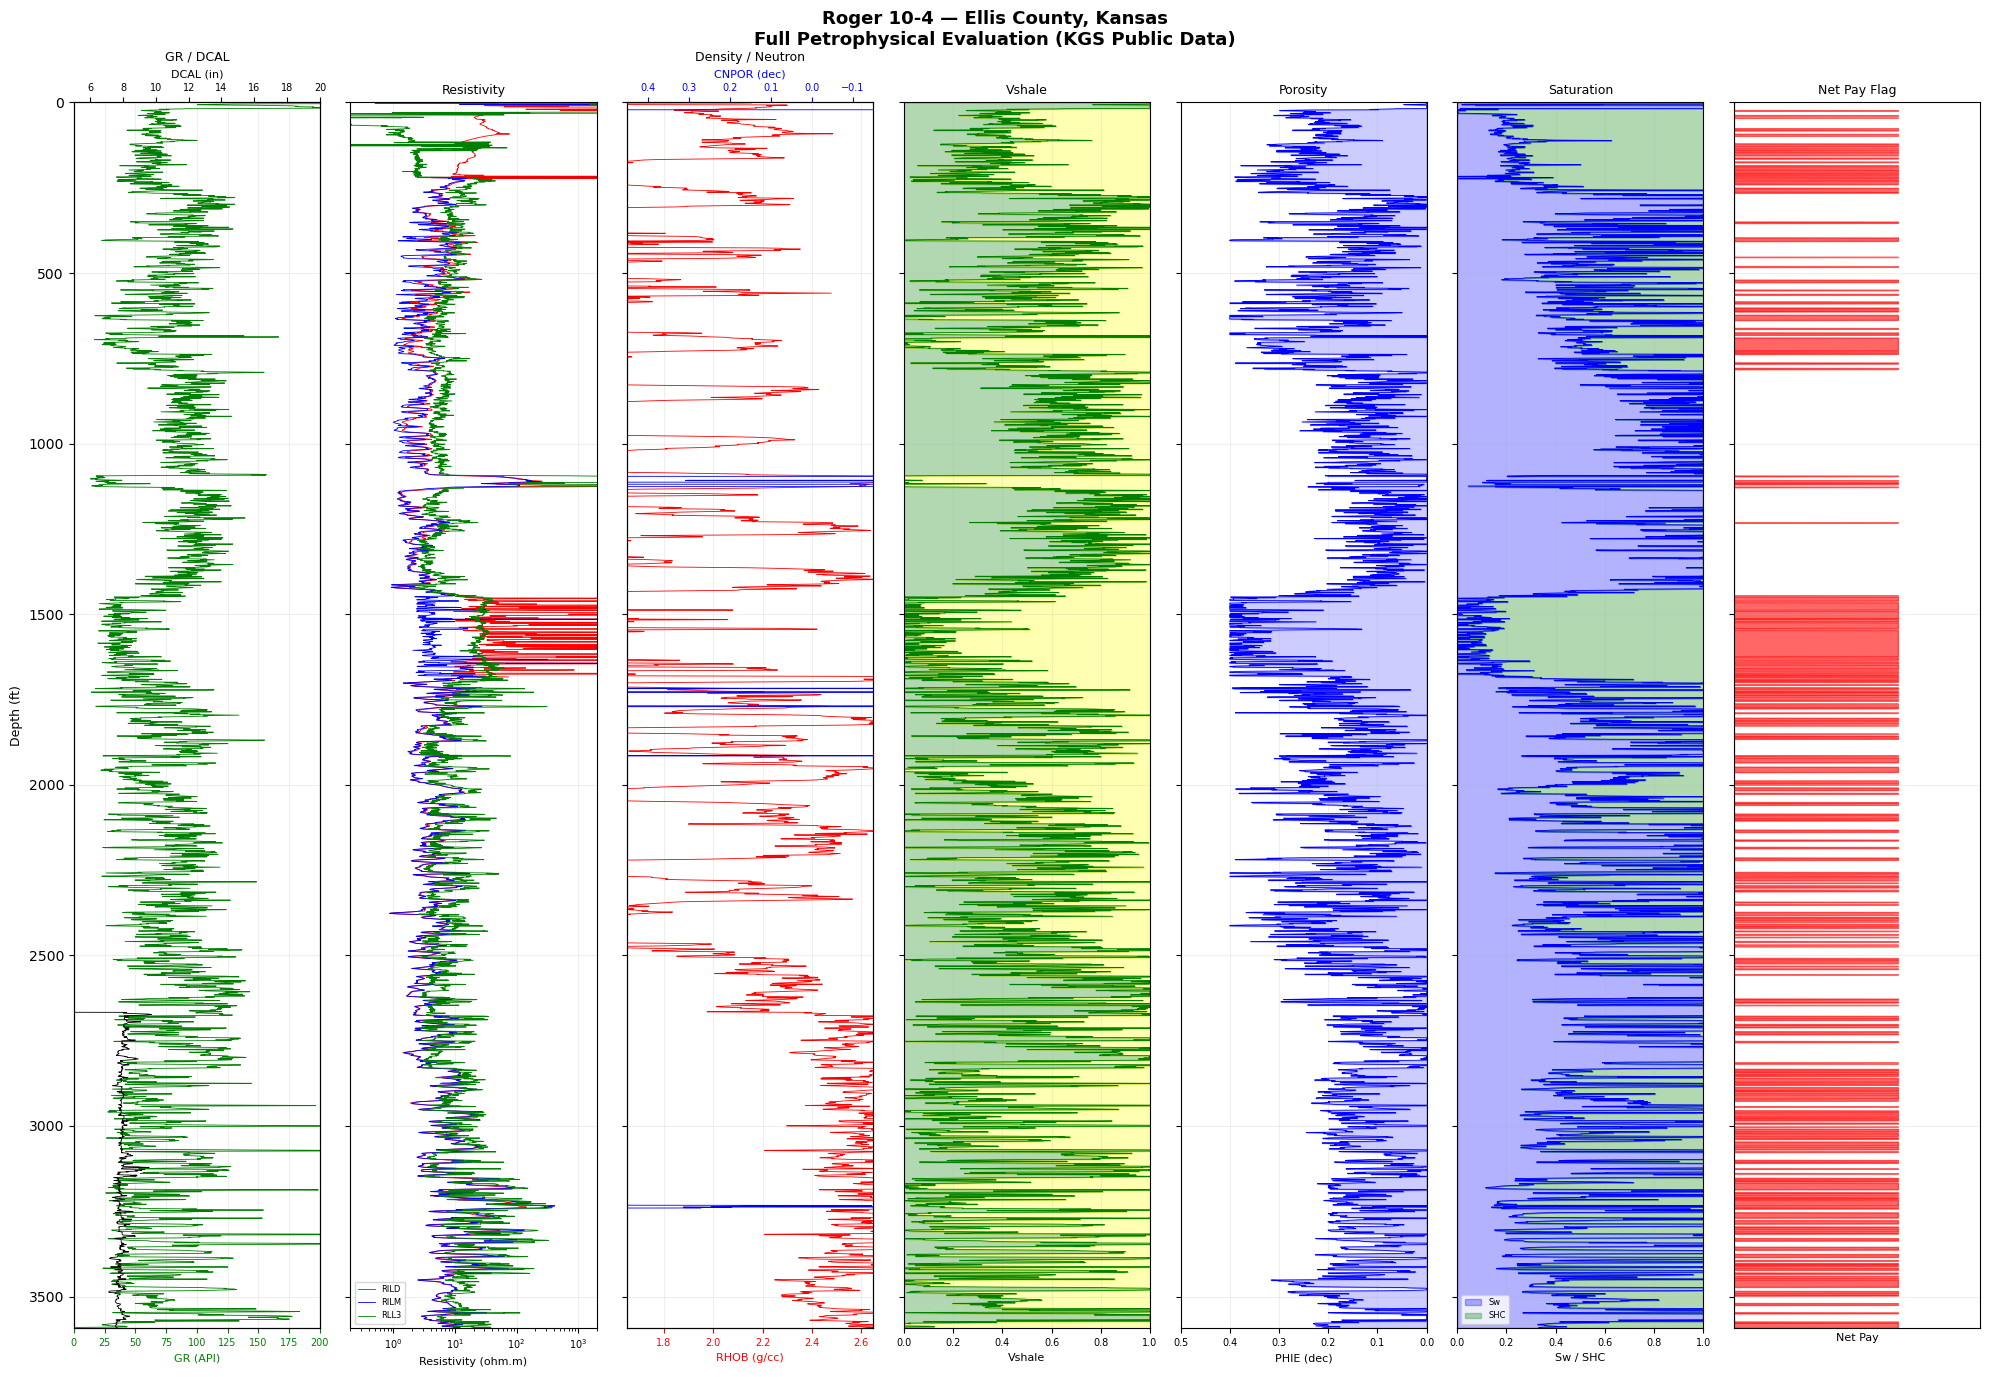

Saved!


In [10]:
# ── 7-Track Full Petrophysical Display ─────────────────────────────────
fig, axes = plt.subplots(1, 7, figsize=(20, 14), sharey=True)
fig.suptitle('Roger 10-4 — Ellis County, Kansas\nFull Petrophysical Evaluation (KGS Public Data)', 
             fontsize=13, fontweight='bold')

depth = df['DEPTH']

# Track 1: GR + Caliper
ax1 = axes[0]
ax1b = ax1.twiny()
ax1.plot(df['GR'], depth, color='green', linewidth=0.6)
ax1b.plot(df['DCAL'], depth, color='black', linewidth=0.6)
ax1.set_xlim(0, 200)
ax1b.set_xlim(5, 20)
ax1.set_xlabel('GR (API)', color='green', fontsize=8)
ax1b.set_xlabel('DCAL (in)', color='black', fontsize=8)
ax1.tick_params(axis='x', colors='green', labelsize=7)
ax1b.tick_params(axis='x', colors='black', labelsize=7)
ax1.set_ylabel('Depth (ft)', fontsize=9)
ax1.set_title('GR / DCAL', fontsize=9)

# Track 2: Resistivity
ax2 = axes[1]
ax2.semilogx(df['RILD'], depth, color='red', linewidth=0.6, label='RILD')
ax2.semilogx(df['RILM'], depth, color='blue', linewidth=0.6, label='RILM')
ax2.semilogx(df['RLL3'], depth, color='green', linewidth=0.6, label='RLL3')
ax2.set_xlim(0.2, 2000)
ax2.set_xlabel('Resistivity (ohm.m)', fontsize=8)
ax2.set_title('Resistivity', fontsize=9)
ax2.legend(fontsize=6)

# Track 3: Density + Neutron
ax3 = axes[2]
ax3b = ax3.twiny()
ax3.plot(df['RHOB'], depth, color='red', linewidth=0.6)
ax3b.plot(df['CNPOR'], depth, color='blue', linewidth=0.6)
ax3.set_xlim(1.65, 2.65)
ax3b.set_xlim(0.45, -0.15)
ax3.set_xlabel('RHOB (g/cc)', color='red', fontsize=8)
ax3b.set_xlabel('CNPOR (dec)', color='blue', fontsize=8)
ax3.tick_params(axis='x', colors='red', labelsize=7)
ax3b.tick_params(axis='x', colors='blue', labelsize=7)
ax3.set_title('Density / Neutron', fontsize=9)

# Track 4: Vshale
ax4 = axes[3]
ax4.plot(df['VSHALE'], depth, color='green', linewidth=0.6)
ax4.fill_betweenx(depth, 0, df['VSHALE'], color='green', alpha=0.3)
ax4.fill_betweenx(depth, df['VSHALE'], 1, color='yellow', alpha=0.3)
ax4.set_xlim(0, 1)
ax4.set_xlabel('Vshale', fontsize=8)
ax4.set_title('Vshale', fontsize=9)

# Track 5: PHIE
ax5 = axes[4]
ax5.plot(df['PHIE'], depth, color='blue', linewidth=0.6)
ax5.fill_betweenx(depth, 0, df['PHIE'], color='blue', alpha=0.2)
ax5.set_xlim(0.5, 0)  # reversed — higher porosity to left
ax5.set_xlabel('PHIE (dec)', fontsize=8)
ax5.set_title('Porosity', fontsize=9)

# Track 6: Water Saturation
ax6 = axes[5]
ax6.plot(df['SW'], depth, color='blue', linewidth=0.6)
ax6.fill_betweenx(depth, 0, df['SW'], color='blue', alpha=0.3, label='Sw')
ax6.fill_betweenx(depth, df['SW'], 1, color='green', alpha=0.3, label='SHC')
ax6.set_xlim(0, 1)
ax6.set_xlabel('Sw / SHC', fontsize=8)
ax6.set_title('Saturation', fontsize=9)
ax6.legend(fontsize=6)

# Track 7: Net Pay Flag
ax7 = axes[6]
net_pay = (df['VSHALE'] < 0.3) & (df['PHIE'] > 0.1) & (df['SW'] < 0.6)
ax7.fill_betweenx(depth, 0, net_pay.astype(int), 
                  color='red', alpha=0.6)
ax7.set_xlim(0, 1.5)
ax7.set_xlabel('Net Pay', fontsize=8)
ax7.set_title('Net Pay Flag', fontsize=9)
ax7.set_xticks([])

# Shared formatting
for ax in axes:
    ax.set_ylim(depth.max(), depth.min())
    ax.grid(True, alpha=0.2)
    ax.tick_params(axis='x', labelsize=7)

plt.tight_layout()
plt.savefig('roger10_4_full_petrophysics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")